# Grundlagen der Künstlichen Intelligenz.
# Exercise 9. Gated Recurrent Unit 

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 9 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

## Time Series Data Loading and Initial Inspection

Load a time series dataset from a CSV file using `pd.read_csv()`. Assume the CSV file has at least one column representing the time or sequence index and one column representing the time series values.

Perform a preliminary inspection of the dataset using `df.head()`, `df.info()`, and `df.describe()`, and visualize the time series using `matplotlib.pyplot`. Note the data types, missing values, and the general trend and seasonality of the time series.

/tmp/ipykernel_23179/2237077491.py:5: DtypeWarning: Columns (0: value) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./Aux/time_series_data.csv', skiprows=1, names=['timestamp', 'value'])


                     value
timestamp                 
1980-01-01 00:00:00    0.0
1980-01-01 01:00:00    0.0
1980-01-01 02:00:00    0.0
1980-01-01 03:00:00    0.0
1980-01-01 04:00:00    0.0
<class 'pandas.DataFrame'>
DatetimeIndex: 350640 entries, 1980-01-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   value   350640 non-null  float64
dtypes: float64(1)
memory usage: 5.4 MB
None
               value
count  350640.000000
mean        0.124625
std         0.181560
min         0.000000
25%         0.000000
50%         0.002000
75%         0.219000
max         0.740000


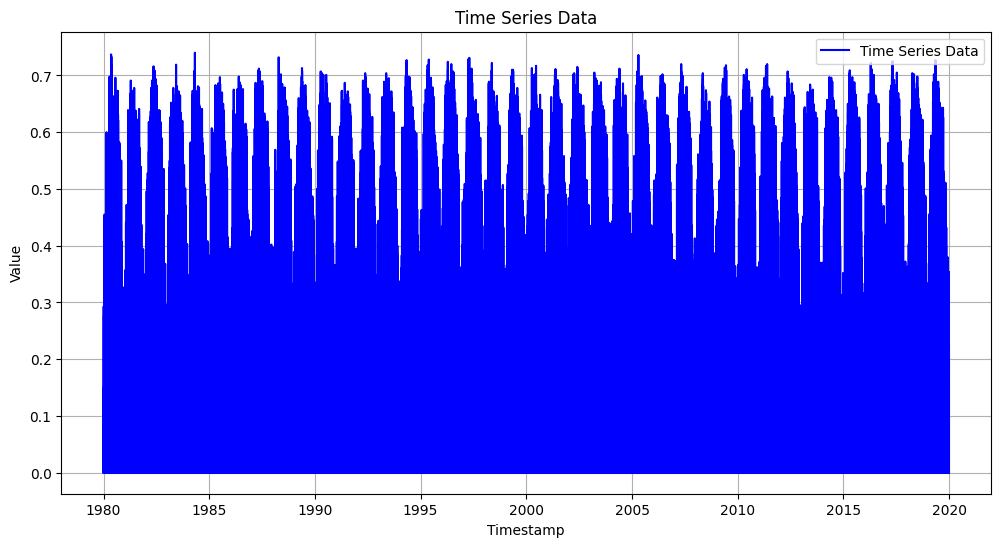

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

data = pd.read_csv('./Aux/time_series_data.csv', skiprows=1, names=['timestamp', 'value'])
data = data[data['timestamp'] != 'time']  # Remove the header row if it was read as data
data['timestamp'] = pd.to_datetime(data['timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
data.dropna(subset=['timestamp'], inplace=True)
data['value'] = pd.to_numeric(data['value'], errors='coerce')
data.dropna(subset=['value'], inplace=True)
data.set_index('timestamp', inplace=True)

print(data.head())
print(data.info())
print(data.describe())

# Plot the time series data
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['value'], label='Time Series Data', color='blue')
plt.title('Time Series Data')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

## Data Preprocessing and Sequence Preparation

Handle missing values in the time series data using appropriate methods (e.g., imputation with mean, median, or forward/backward fill). Justify your choice.

In [2]:
print("Number of missing values in 'value' column:", data['value'].isna().sum())

# Since the data is already cleaned, no imputation is necessary. However, if there were missing values, we could use forward fill or backward fill methods to impute them, as they are suitable for time series data where the previous or next value can be a reasonable estimate for the missing value.

Number of missing values in 'value' column: 0


Scale the numerical time series data using `StandardScaler()`.

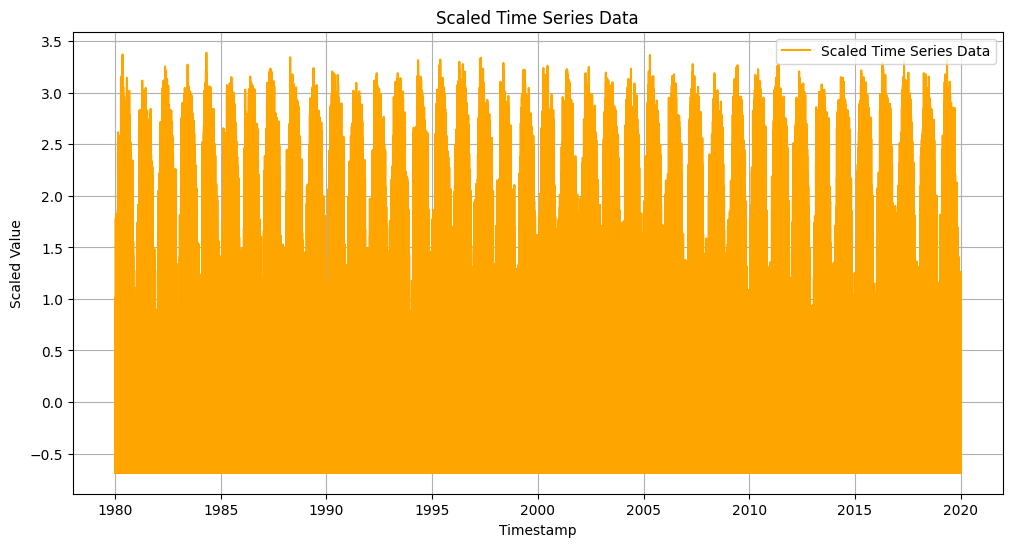

In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data['value_scaled'] = scaler.fit_transform(data[['value']])

# Plot the scaled time series data
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['value_scaled'], label='Scaled Time Series Data', color='orange')
plt.title('Scaled Time Series Data')
plt.xlabel('Timestamp')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid()
plt.show()

Prepare the data for sequence learning by creating sequences of a fixed length. Define a `create_sequences()` function that takes the time series data and a sequence length as input and returns sequences and their corresponding next values (targets).

In [4]:
import numpy as np
def create_sequences(data, sequence_length):
    sequences = []
    targets = []
    for i in range(len(data) - sequence_length):
        seq = data[i:i + sequence_length]
        target = data[i + sequence_length]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

sequence_length = 20
X, y = create_sequences(data['value_scaled'].values, sequence_length)
print("Shape of sequences:", X.shape)
print("Shape of targets:", y.shape)

Shape of sequences: (350620, 20)
Shape of targets: (350620,)


Split the sequences into training (80%) and testing (20%) sets. Document your chosen
random state if any shuffling is involved (consider the temporal nature of the data).

In [5]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 280496
Testing set size: 70124


Convert the sequences and targets to PyTorch tensors. Reshape the input sequences to be 3D tensors of shape (`batch_size`, `seq_length`, `num_features`).

In [6]:
import torch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # Add feature dimension
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print("Shape of X_train_tensor:", X_train_tensor.shape)
print("Shape of y_train_tensor:", y_train_tensor.shape)
print("Shape of X_test_tensor:", X_test_tensor.shape)
print("Shape of y_test_tensor:", y_test_tensor.shape)

Shape of X_train_tensor: torch.Size([280496, 20, 1])
Shape of y_train_tensor: torch.Size([280496])
Shape of X_test_tensor: torch.Size([70124, 20, 1])
Shape of y_test_tensor: torch.Size([70124])


Create PyTorch `DataLoader` objects for training and testing.

In [7]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("Number of batches in training set:", len(train_loader))
print("Number of batches in testing set:", len(test_loader))

Number of batches in training set: 8766
Number of batches in testing set: 2192


## GRU Network Architecture Design and Training (PyTorch)

- Design and train a GRU-based neural network model using PyTorch. Use the provided `SimpleGRU` class as a starting point.
- Train the model for a suitable number of epochs (e.g., 100) using the `train_model()` method.
- Store the training history (loss) for your model.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_units, output_size, num_layers=1, learning_rate=0.001):
        super(SimpleGRU, self).__init__()
        self.hidden_size = hidden_units
        self.num_layers = num_layers
        self.learning_rate = learning_rate

        self.GRU = nn.GRU(input_size, hidden_units, num_layers, batch_first=True)
        self.LinearLayer = nn.Linear(hidden_units, output_size)

        self.Optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        self.Criterion = nn.MSELoss()

    def forward(self, input):
        batch_size = input.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(input.device)

        out, _ = self.GRU(input, h0)
        out = self.LinearLayer(out[:, -1, :])  # Use the last time
        return out

    def train_step(self, input, target):
        self.Optimizer.zero_grad()
        output = self.forward(input)
        loss = self.Criterion(output.squeeze(), target)
        loss.backward()
        self.Optimizer.step()
        return loss.item()
    
    def train_model(self, train_loader, num_epochs=100):
        print("Starting training...")
        self.train()
        history = []
        for epoch in range(num_epochs):
            epoch_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(next(self.parameters()).device), batch_y.to(next(self.parameters()).device)
                loss = self.train_step(batch_X, batch_y)
                epoch_loss += loss
            average_loss = epoch_loss / len(train_loader)
            history.append(average_loss)
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}')
        return history

    def evaluate(self, test_loader, scaler):
        self.eval()
        
        total_loss = 0
        total_samples = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(next(self.parameters()).device), batch_y.to(next(self.parameters()).device)
                output = self.forward(batch_X)
                loss = self.Criterion(output.squeeze(), batch_y)
                total_loss += loss.item() * batch_X.size(0)
                total_samples += batch_X.size(0)
        return total_loss / total_samples

    def train_model_with_test_loss(self, train_loader, test_loader, num_epochs=100):
        print("Starting training with test loss evaluation...")
        train_losses = []
        test_losses = []
        for epoch in range(num_epochs):
            self.train()
            epoch_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(next(self.parameters()).device), batch_y.to(next(self.parameters()).device)
                loss = self.train_step(batch_X, batch_y)
                epoch_loss += loss
            average_train_loss = epoch_loss / len(train_loader)
            train_losses.append(average_train_loss)

            test_loss = self.evaluate(test_loader, scaler)
            test_losses.append(test_loss)

            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {average_train_loss:.4f}, Test Loss: {test_loss:.4f}')
        return train_losses, test_losses


In [9]:
input_size = 1  # Since we have only one feature (the scaled value)
hidden_units = 64
output_size = 1  # Predicting a single value (the next time step)
num_layers = 2
learning_rate = 0.005

model = SimpleGRU(input_size, hidden_units, output_size, num_layers, learning_rate)

## Model Evaluation and Performance Analysis (PyTorch)

- Evaluate the performance of your GRU model on the test set using a suitable evaluation metric for time series forecasting (e.g., Mean Squared Error - MSE, Mean Absolute Error - MAE). Implement an evaluate() method. Remember to inverse transform the scaled predictions back to the original scale for meaningful evaluation.
- Discuss the trade-offs between model complexity (number of layers, hidden units) and performance for time series forecasting.
- Analyze the training loss curve. Identify signs of overfitting or underfitting. Discuss
possible remedies specific to sequence models (e.g., early stopping, regularization).

In [ ]:
train_losses, test_losses = model.train_model_with_test_loss(train_loader, test_loader, num_epochs=100)
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(test_losses, label='Testing Loss', color='orange')
plt.title('Training and Testing Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# // TODO: 40min y solo 10 epochs

Starting training with test loss evaluation...
Epoch 1/100, Train Loss: 0.0042, Test Loss: 0.0023
Epoch 2/100, Train Loss: 0.0021, Test Loss: 0.0015
Epoch 3/100, Train Loss: 0.0019, Test Loss: 0.0015
Epoch 4/100, Train Loss: 0.0018, Test Loss: 0.0016
Epoch 5/100, Train Loss: 0.0017, Test Loss: 0.0018
Epoch 6/100, Train Loss: 0.0017, Test Loss: 0.0015
Epoch 7/100, Train Loss: 0.0016, Test Loss: 0.0016
Epoch 8/100, Train Loss: 0.0016, Test Loss: 0.0015
Epoch 9/100, Train Loss: 0.0016, Test Loss: 0.0016
Epoch 10/100, Train Loss: 0.0015, Test Loss: 0.0017


KeyboardInterrupt: 